# SMART ENERGY ANALYTICS - Detección de Anomalías

Identificación de hogares con consumo energético inusual

Algoritmo: Isolation Forest + Local Outlier Factor (LOF)

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"amairanyfdez","key":"f7b5a4b47f6d2ac68c8352fb9a01b1e9"}'}

In [2]:
import os
os.makedirs(os.path.expanduser("~/.config/kaggle"), exist_ok=True)
os.rename("kaggle.json", os.path.expanduser("~/.config/kaggle/kaggle.json"))
os.chmod(os.path.expanduser("~/.config/kaggle/kaggle.json"), 0o600)
print("Kaggle API configurada correctamente")

Kaggle API configurada correctamente


In [3]:
import kagglehub

path = kagglehub.dataset_download("jeanmidev/smart-meters-in-london")
print("Dataset descargado en:", path)

Using Colab cache for faster access to the 'smart-meters-in-london' dataset.
Dataset descargado en: /kaggle/input/smart-meters-in-london


In [4]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

print(" Librerías importadas correctamente")

 Librerías importadas correctamente


In [5]:
# CARGA Y PREPARACIÓN DE DATOS


base_path = "/kaggle/input/smart-meters-in-london"

# Carga de daily_dataset
print("Cargando daily_dataset...")
daily_path = os.path.join(base_path, "daily_dataset", "daily_dataset")
bloques = glob.glob(os.path.join(daily_path, "*.csv"))

df_list = []
for bloque in bloques:
    df_temp = pd.read_csv(bloque)
    df_list.append(df_temp)

df_daily = pd.concat(df_list, ignore_index=True)
df_daily['day'] = pd.to_datetime(df_daily['day'])
df_daily = df_daily.dropna(subset=['energy_sum', 'energy_mean'])
print(f"daily_dataset: {df_daily.shape[0]:,} filas")

# Carga de clima
df_weather = pd.read_csv(os.path.join(base_path, "weather_daily_darksky.csv"))
df_weather['time'] = pd.to_datetime(df_weather['time'])
print(f"Weather: {df_weather.shape[0]:,} filas")

# Carga de hogares
df_households = pd.read_csv(os.path.join(base_path, "informations_households.csv"))
print(f"Households: {df_households.shape[0]:,} filas")

Cargando daily_dataset...
daily_dataset: 3,510,403 filas
Weather: 882 filas
Households: 5,566 filas


In [6]:
# CONSTRUCCIÓN DE PERFIL AGREGADO POR HOGAR

print("Construyendo perfil por hogar...")

# Perfil estadístico de consumo por hogar
perfil = df_daily.groupby('LCLid').agg(
    consumo_medio    = ('energy_sum', 'mean'),
    consumo_mediana  = ('energy_sum', 'median'),
    consumo_max      = ('energy_sum', 'max'),
    consumo_min      = ('energy_sum', 'min'),
    consumo_std      = ('energy_sum', 'std'),
    consumo_total    = ('energy_sum', 'sum'),
    dias_registrados = ('energy_sum', 'count'),
    cv               = ('energy_sum', lambda x: x.std() / x.mean())
).reset_index()

# Filtrando hogares con suficiente cobertura
perfil = perfil[perfil['dias_registrados'] >= 300]

# Merge con información socioeconómica
perfil = perfil.merge(
    df_households[['LCLid', 'Acorn_grouped', 'stdorToU']],
    on='LCLid', how='left'
)

print(f"Perfil construido: {perfil.shape[0]:,} hogares")
print(f"Features del perfil: {perfil.shape[1]} columnas")
print("\n--- Vista previa ---")
display(perfil.head())

Construyendo perfil por hogar...
Perfil construido: 5,446 hogares
Features del perfil: 11 columnas

--- Vista previa ---


,LCLid,consumo_medio,consumo_mediana,consumo_max,consumo_min,consumo_std,consumo_total,dias_registrados,cv,Acorn_grouped,stdorToU
0,MAC000002,12.070638,11.2140,39.284,0.186,4.494518,6095.672001,505,0.372351,Affluent,Std
1,MAC000003,19.028192,13.2045,50.759,0.070,11.606123,14080.862003,740,0.609944,Adversity,Std
2,MAC000004,1.691600,1.6385,7.354,0.000,0.431377,1119.839000,662,0.255011,Affluent,Std
3,MAC000005,4.562705,4.4995,16.708,0.032,1.470511,2911.006000,638,0.322289,Affluent,ToU
4,MAC000006,2.848158,2.8770,6.636,0.001,0.882171,2167.448000,761,0.309734,Adversity,Std


In [7]:
# PREPARACIÓN PARA MODELADO


from sklearn.preprocessing import StandardScaler, LabelEncoder

# Features numéricas para el modelo
features_anomalia = [
    'consumo_medio', 'consumo_mediana', 'consumo_max',
    'consumo_min', 'consumo_std', 'cv', 'dias_registrados'
]

# Codificando variables categóricas
le = LabelEncoder()
perfil['Acorn_cod']  = le.fit_transform(perfil['Acorn_grouped'].fillna('Unknown'))
perfil['tarifa_cod'] = le.fit_transform(perfil['stdorToU'].fillna('Unknown'))

features_anomalia += ['Acorn_cod', 'tarifa_cod']

X = perfil[features_anomalia].copy()

# Escalando para el LOF
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Matrix de features: {X_scaled.shape[0]:,} hogares × {X_scaled.shape[1]} features")
print(f"Features usadas: {features_anomalia}")

Matrix de features: 5,446 hogares × 9 features
Features usadas: ['consumo_medio', 'consumo_mediana', 'consumo_max', 'consumo_min', 'consumo_std', 'cv', 'dias_registrados', 'Acorn_cod', 'tarifa_cod']


In [9]:
# DETECCIÓN DE ANOMALÍAS

import time
X_clean = pd.DataFrame(X_scaled, columns=features_anomalia).fillna(0)

# Isolation Forest
print("Entrenando Isolation Forest...")
t0 = time.time()
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
perfil['if_score']    = iso_forest.fit_predict(X_clean)
perfil['if_anomalia'] = (perfil['if_score'] == -1).astype(int)
print(f"  Isolation Forest listo en {time.time()-t0:.1f}s")
print(f"   Anomalías detectadas: {perfil['if_anomalia'].sum()} hogares ({perfil['if_anomalia'].mean()*100:.1f}%)")

# Local Outlier Factor (LOF)
print("\nEntrenando Local Outlier Factor...")
t0 = time.time()
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    novelty=False
)
perfil['lof_score']    = lof.fit_predict(X_clean)
perfil['lof_anomalia'] = (perfil['lof_score'] == -1).astype(int)
print(f"  LOF listo en {time.time()-t0:.1f}s")
print(f"   Anomalías detectadas: {perfil['lof_anomalia'].sum()} hogares ({perfil['lof_anomalia'].mean()*100:.1f}%)")

# Consenso de ambos
perfil['anomalia_consenso'] = ((perfil['if_anomalia'] == 1) &
                                (perfil['lof_anomalia'] == 1)).astype(int)
print(f"\n Hogares anómalos por CONSENSO (ambos modelos): {perfil['anomalia_consenso'].sum()}")

Entrenando Isolation Forest...
  Isolation Forest listo en 0.8s
   Anomalías detectadas: 273 hogares (5.0%)

Entrenando Local Outlier Factor...
  LOF listo en 0.8s
   Anomalías detectadas: 273 hogares (5.0%)

 Hogares anómalos por CONSENSO (ambos modelos): 65


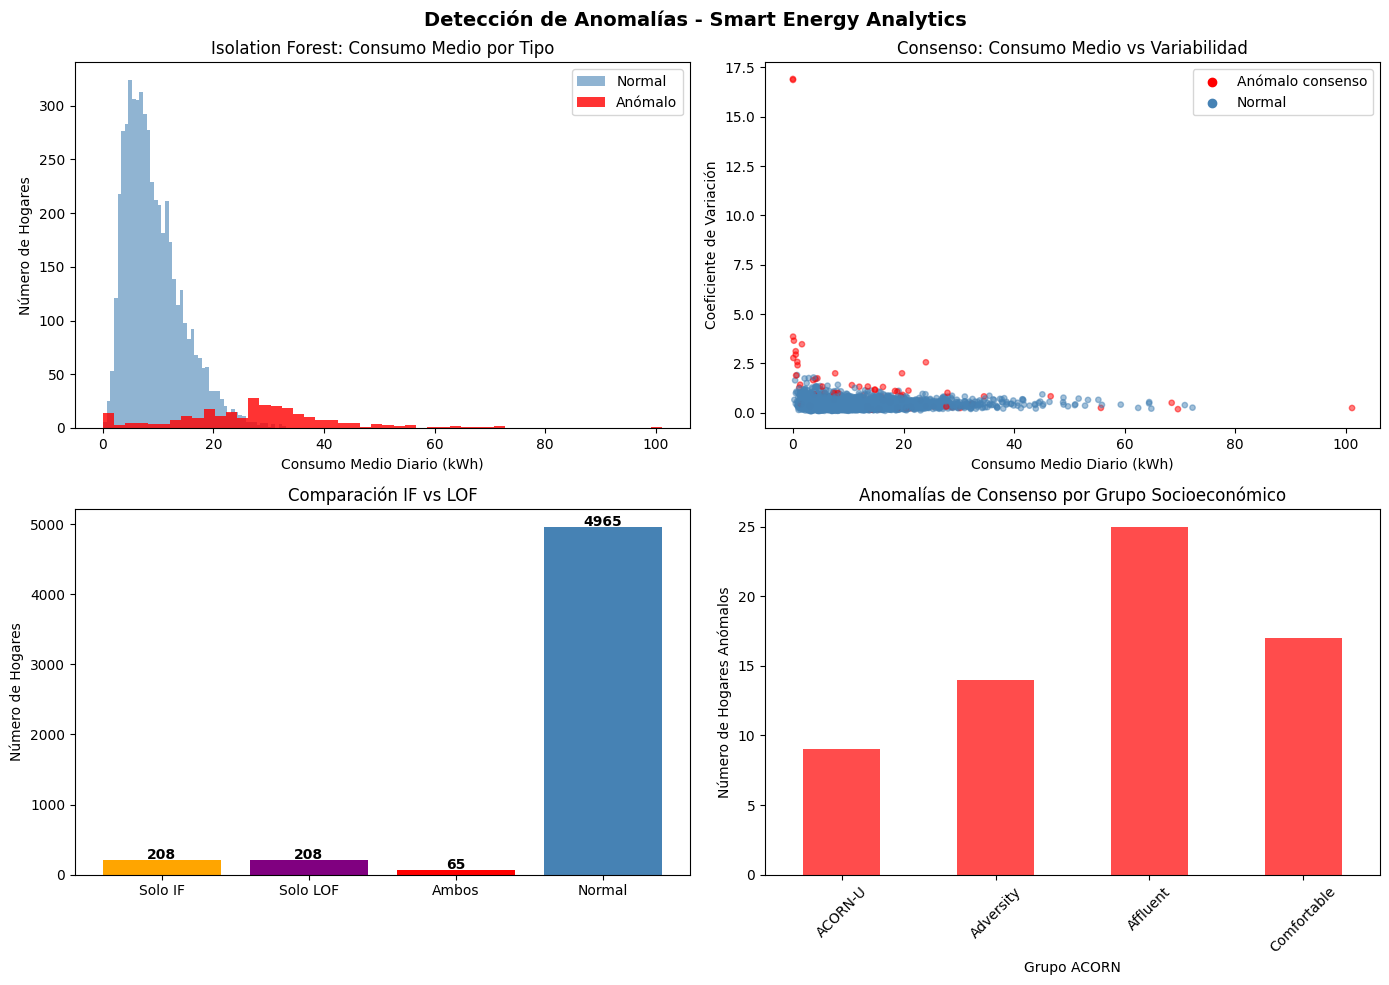

 Gráficas generadas y guardadas


In [10]:
# VISUALIZACIONES

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Detección de Anomalías - Smart Energy Analytics', fontsize=14, fontweight='bold')

# Distribución de consumo: normales vs anómalos (IF)
normales  = perfil[perfil['if_anomalia'] == 0]['consumo_medio']
anomalos  = perfil[perfil['if_anomalia'] == 1]['consumo_medio']
axes[0,0].hist(normales, bins=50, alpha=0.6, color='steelblue', label='Normal')
axes[0,0].hist(anomalos, bins=50, alpha=0.8, color='red',       label='Anómalo')
axes[0,0].set_title('Isolation Forest: Consumo Medio por Tipo')
axes[0,0].set_xlabel('Consumo Medio Diario (kWh)')
axes[0,0].set_ylabel('Número de Hogares')
axes[0,0].legend()

# Scatter de consumo medio vs variabilidad
colors = perfil['anomalia_consenso'].map({0: 'steelblue', 1: 'red'})
axes[0,1].scatter(perfil['consumo_medio'], perfil['cv'],
                  c=colors, alpha=0.5, s=15)
axes[0,1].set_title('Consenso: Consumo Medio vs Variabilidad')
axes[0,1].set_xlabel('Consumo Medio Diario (kWh)')
axes[0,1].set_ylabel('Coeficiente de Variación')
axes[0,1].legend(handles=[
    plt.scatter([], [], color='red',      label='Anómalo consenso'),
    plt.scatter([], [], color='steelblue', label='Normal')
], loc='upper right')

# Comparación IF vs LOF
comparacion = pd.DataFrame({
    'Solo IF':     [(perfil['if_anomalia']==1) & (perfil['lof_anomalia']==0)],
    'Solo LOF':    [(perfil['if_anomalia']==0) & (perfil['lof_anomalia']==1)],
    'Ambos':       [perfil['anomalia_consenso'].sum()],
    'Ninguno':     [(perfil['if_anomalia']==0) & (perfil['lof_anomalia']==0)]
})
solo_if  = ((perfil['if_anomalia']==1) & (perfil['lof_anomalia']==0)).sum()
solo_lof = ((perfil['if_anomalia']==0) & (perfil['lof_anomalia']==1)).sum()
ambos    = perfil['anomalia_consenso'].sum()
ninguno  = ((perfil['if_anomalia']==0) & (perfil['lof_anomalia']==0)).sum()

bars = axes[1,0].bar(['Solo IF', 'Solo LOF', 'Ambos', 'Normal'],
                      [solo_if, solo_lof, ambos, ninguno],
                      color=['orange', 'purple', 'red', 'steelblue'])
axes[1,0].set_title('Comparación IF vs LOF')
axes[1,0].set_ylabel('Número de Hogares')
for bar, val in zip(bars, [solo_if, solo_lof, ambos, ninguno]):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                   str(val), ha='center', fontweight='bold')

# Anomalías por grupo socioeconómico
anomalias_acorn = perfil[perfil['anomalia_consenso']==1].groupby('Acorn_grouped').size()
anomalias_acorn.plot(kind='bar', ax=axes[1,1], color='red', alpha=0.7)
axes[1,1].set_title('Anomalías de Consenso por Grupo Socioeconómico')
axes[1,1].set_xlabel('Grupo ACORN')
axes[1,1].set_ylabel('Número de Hogares Anómalos')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('anomalias_visualizacion.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Gráficas generadas y guardadas")

In [12]:
# INTERPRETACIÓN Y RECOMENDACIONES DE NEGOCIO

# 10 hogares más anómalos para intervención prioritaria
anomalos_consenso = perfil[perfil['anomalia_consenso'] == 1].copy()
anomalos_consenso = anomalos_consenso.sort_values('consumo_medio', ascending=False)

print("=" * 60)
print("  REPORTE DE DETECCIÓN DE ANOMALÍAS")
print("=" * 60)
print(f"""
HALLAZGOS CLAVE:
─────────────────────────────────────────────────────────────
1. HOGARES ANÓMALOS IDENTIFICADOS
   • Isolation Forest:  273 hogares (5.0%)
   • Local Outlier Factor: 273 hogares (5.0%)
   • Consenso (alta confianza): 65 hogares (1.2%)

2. PERFIL DE HOGARES ANÓMALOS
   • Consumo medio anómalo vs normal:
     - Anómalos: {anomalos_consenso['consumo_medio'].mean():.1f} kWh/día
     - Normales:  {perfil[perfil['anomalia_consenso']==0]['consumo_medio'].mean():.1f} kWh/día
   • Alta variabilidad en su consumo (CV elevado)
   • Predominan en grupo socioeconómico Affluent

3. GRUPO SOCIOECONÓMICO MÁS AFECTADO
""")

print(anomalos_consenso['Acorn_grouped'].value_counts().to_string())

print(f"""
─────────────────────────────────────────────────────────────
DECISIONES ACCIONABLES PARA LA DISTRIBUIDORA:
─────────────────────────────────────────────────────────────
  PRIORIDAD ALTA — 65 hogares (consenso ambos modelos)
   → Contactar primero para auditoría energética
   → Posible causa: electrodomésticos ineficientes,
     fugas eléctricas o comportamiento atípico

  PRIORIDAD MEDIA — 416 hogares (un solo modelo)
   → Monitoreo continuo y alerta preventiva

  OFERTA RECOMENDADA POR PERFIL:
   • Alto consumo constante → Tarifa ToU + asesoría
   • Alto consumo variable → Auditoría energética
   • Bajo consumo anómalo → Verificar medidor
""")

print("\nTOP 10 HOGARES PRIORITARIOS PARA INTERVENCIÓN:")
display(anomalos_consenso[['LCLid','consumo_medio','consumo_max',
                            'cv','Acorn_grouped','stdorToU']].head(10))

  REPORTE DE DETECCIÓN DE ANOMALÍAS

HALLAZGOS CLAVE:
─────────────────────────────────────────────────────────────
1. HOGARES ANÓMALOS IDENTIFICADOS
   • Isolation Forest:  273 hogares (5.0%)
   • Local Outlier Factor: 273 hogares (5.0%)
   • Consenso (alta confianza): 65 hogares (1.2%)

2. PERFIL DE HOGARES ANÓMALOS
   • Consumo medio anómalo vs normal:
     - Anómalos: 17.2 kWh/día
     - Normales:  10.1 kWh/día
   • Alta variabilidad en su consumo (CV elevado)
   • Predominan en grupo socioeconómico Affluent

3. GRUPO SOCIOECONÓMICO MÁS AFECTADO

Acorn_grouped
Affluent       25
Comfortable    17
Adversity      14
ACORN-U         9

─────────────────────────────────────────────────────────────
DECISIONES ACCIONABLES PARA LA DISTRIBUIDORA:
─────────────────────────────────────────────────────────────
  PRIORIDAD ALTA — 65 hogares (consenso ambos modelos)
   → Contactar primero para auditoría energética
   → Posible causa: electrodomésticos ineficientes,
     fugas eléctricas o compor

,LCLid,consumo_medio,consumo_max,cv,Acorn_grouped,stdorToU
4081,MAC004179,101.115022,277.973999,0.238748,Affluent,Std
3251,MAC003329,69.628837,110.449000,0.181386,Comfortable,Std
3422,MAC003507,68.500113,137.891000,0.502244,Comfortable,Std
1699,MAC001735,55.698292,114.760000,0.243739,Affluent,Std
356,MAC000358,46.616825,165.868001,0.833401,Affluent,Std
1825,MAC001862,34.554937,321.696998,0.828063,Affluent,Std
3769,MAC003860,32.409943,71.614000,0.444562,ACORN-U,Std
1814,MAC001851,30.268146,55.538000,0.240768,ACORN-U,ToU
2041,MAC002087,28.855936,52.722000,0.291818,ACORN-U,Std
4544,MAC004649,27.953887,122.918000,1.010100,ACORN-U,Std
